Kiểm chứng tính chất Idempotent

Thiết lập đường dẫn để dảm bảo import an toàn

In [1]:
import os
import sys
# Lấy đường dẫn thư mục hiện tại của Notebook
current_dir = os.getcwd() 
# parent_dir sẽ là thư mục gốc LAB2
parent_dir = os.path.dirname(current_dir)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [2]:
from part1.linalg import Matrix
from part1.ols_implementation import hat_matrix

Lập ma trận X

In [3]:
X = Matrix([
    [1, 1],
    [1, 2],
    [1, 3],
    [1, 4],
    [1, 5]
])

Tính ma trận hat của X

In [4]:
H = hat_matrix(X)

print(H)

[(0.60    0.40    0.20    0.00    -0.20),
 (0.40    0.30    0.20    0.10    -0.00),
 (0.20    0.20    0.20    0.20    0.20),
 (-0.00    0.10    0.20    0.30    0.40),
 (-0.20    0.00    0.20    0.40    0.60)]


Kiểm chứng H*H = H

In [5]:
H2 = H * H

print(H2)

[(0.60    0.40    0.20    -0.00    -0.20),
 (0.40    0.30    0.20    0.10    -0.00),
 (0.20    0.20    0.20    0.20    0.20),
 (-0.00    0.10    0.20    0.30    0.40),
 (-0.20    0.00    0.20    0.40    0.60)]


In [6]:
print(H * H == H)

True


Monte Carlo

In [7]:
from part1.cross_validation import run_monte_carlo
import matplotlib.pyplot as plt

In [8]:
# Cấu hình tham số
B0, B1 = 3.0, 2.0
results = run_monte_carlo(n_simulations=1000, beta0=B0, beta1=B1)

print(f"{'Parameter':<15} | {'True Value':<10} | {'Estimated Mean':<15}")
print("-" * 45)
print(f"{'Beta 0':<15} | {B0:<10} | {results['beta0_mean']:.4f}")
print(f"{'Beta 1':<15} | {B1:<10} | {results['beta1_mean']:.4f}")

Parameter       | True Value | Estimated Mean 
---------------------------------------------
Beta 0          | 3.0        | 3.0045
Beta 1          | 2.0        | 2.0001


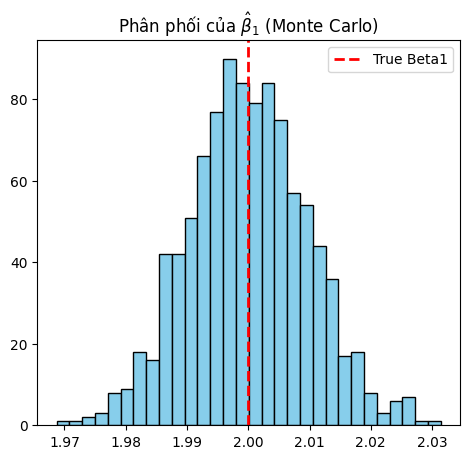

In [9]:
plt.figure(figsize=(12, 5))

# Vẽ phân phối của Beta 1
plt.subplot(1, 2, 1)
plt.hist(results['beta1_hats'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(B1, color='red', linestyle='dashed', linewidth=2, label='True Beta1')
plt.title(r'Phân phối của $\hat{\beta}_1$ (Monte Carlo)')
plt.legend()

plt.show()